# Predicting Wine Quality Using Gradient Boosting Classifier

### Boosting technique to imporove model performance by minimizing prediction errors step by step

In [4]:
# Import Required Library

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load the Dataset(Direct from UCI)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep = ';') # ';' is the delimiter

In [6]:
df['label']=df['quality'].apply(lambda x: 1 if x>=7 else 0)

In [8]:
df =df.drop('quality',axis =1)

In [9]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [10]:
#Train_test_split
X = df.drop('label',axis =1)
y = df['label']

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state=42, stratify = y)

In [13]:
#Balance Data using SMOTE
smote = SMOTE(random_state = 42)
X_train_res,y_train_res = smote.fit_resample(X_train,y_train)

#print class distribution after balancing
print("After SMOTE:", np.bincount(y_train_res))

After SMOTE: [1105 1105]


In [14]:
#Initialize and Train Gradient Boosting Classifier

gb_model = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state =42
)

In [15]:
gb_model.fit(X_train_res,y_train_res)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [16]:
#Make prediction and Evaluate
y_pred = gb_model.predict(X_test)

In [18]:
#Classification Performance
print("Classification Report:\n", classification_report(y_test,y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93       277
           1       0.54      0.70      0.61        43

    accuracy                           0.88       320
   macro avg       0.74      0.80      0.77       320
weighted avg       0.89      0.88      0.88       320




 Confusion Matrix:



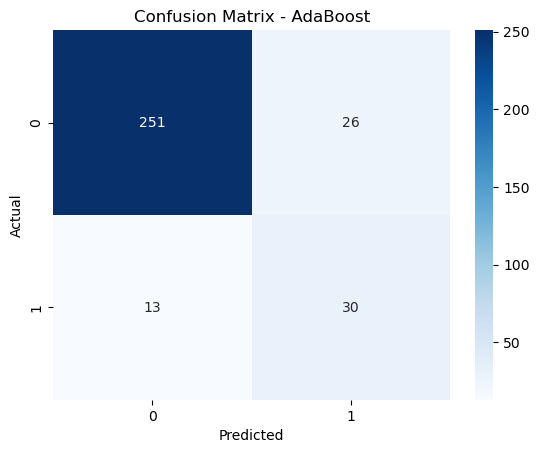

In [19]:
print("\n Confusion Matrix:\n")
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot = True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - AdaBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

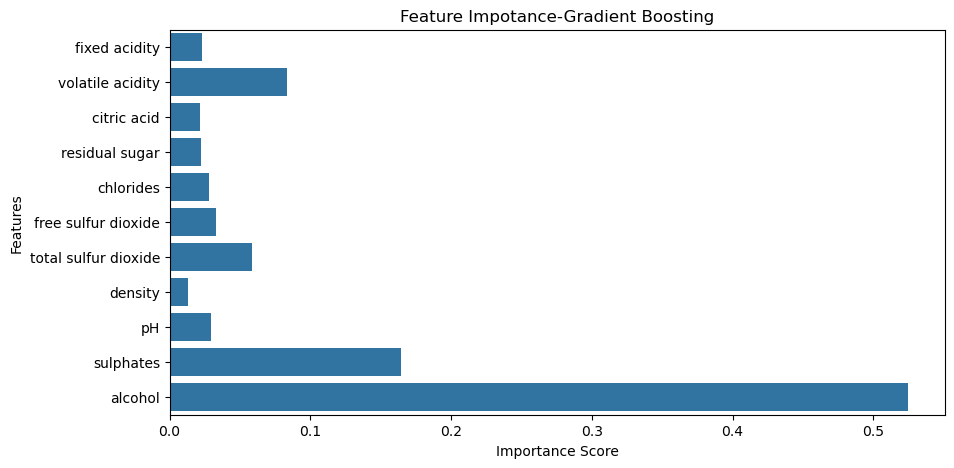

In [20]:
# Feature Importance Plot

importances = gb_model.feature_importances_
features=X.columns

# Create a bar plot
plt.figure(figsize=(10,5))
sns.barplot(x= importances, y = features)
plt.title("Feature Impotance-Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()